In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

data = pd.read_csv(url, sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<Axes: >

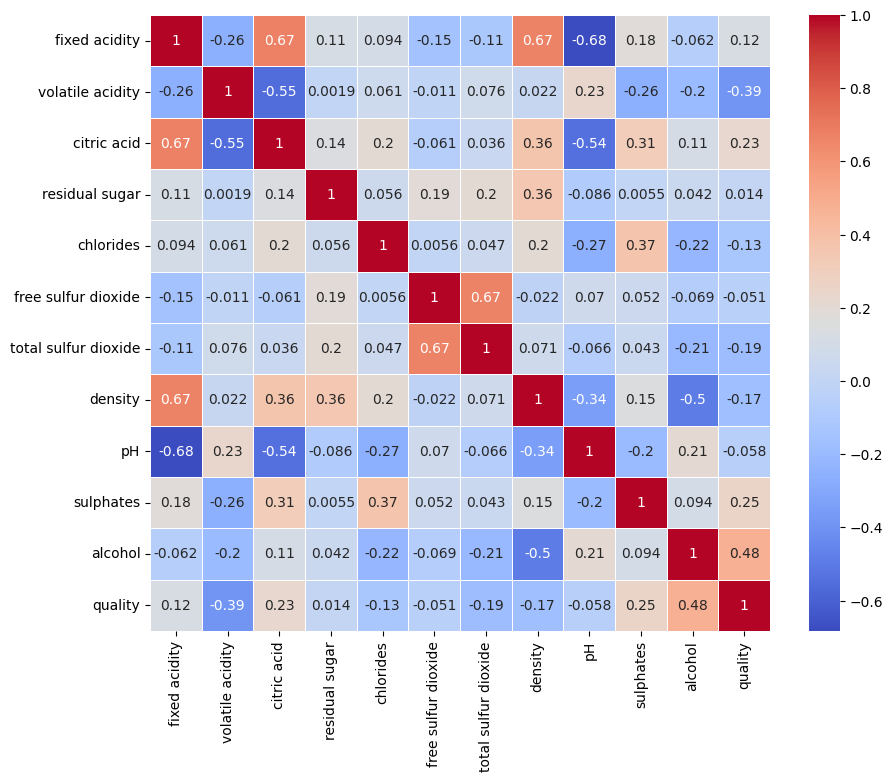

In [4]:
# check the correlation between each features
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

C:\Users\Pablo\AppData\Local\Temp\ipykernel_15484\3050591222.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0.5, 1.0, 'Boxplot of Features')

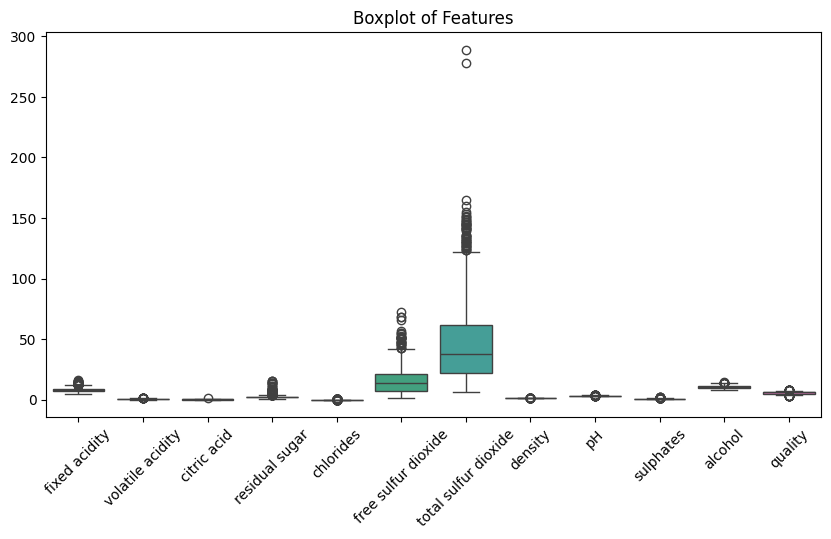

In [5]:
# box plot of features
fig, ax = plt.subplots(1, figsize=(10, 5))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Boxplot of Features")
# we can see that the data is not normalized

In [ ]:
# normalize the data --> normally it is better to normalize the data after splitting it into train and test sets
# check metaparameters2 and metaparameters3 for better ways to normalize the data
cols_to_normalize = data.drop("quality", axis=1).columns
for col in cols_to_normalize:
    mean = data[col].mean()
    stdev = data[col].std()
    data[col] = (data[col] - mean) / stdev

# or more compactly using stats.zscore or StandardScaler from sklearn
# data[cols_to_normalize] = data[cols_to_normalize].apply(stats.zscore)
# or using StandardScaler
# scaler = StandardScaler()
# data[cols_to_normalize] = scaler.fit_transform(data[cols_to_normalize])

C:\Users\Pablo\AppData\Local\Temp\ipykernel_15484\4080538110.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0.5, 1.0, 'Boxplot of Features')

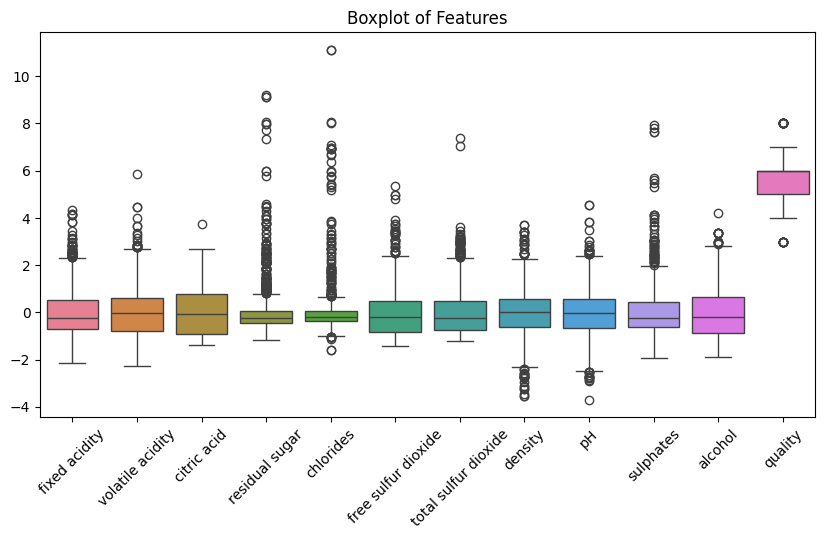

In [7]:
fig, ax = plt.subplots(1, figsize=(10, 5))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Boxplot of Features")

# now the mean is 0 and the stdev is 1 for all features or at least close to that, except the target variable.

Text(0.5, 1.0, 'Distribution of Target Variable')

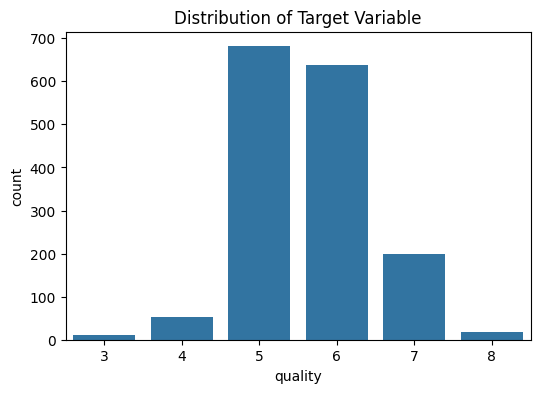

In [8]:
# check if the target variable is balanced
plt.figure(figsize=(6, 4))
sns.countplot(x="quality", data=data)
plt.title("Distribution of Target Variable")

In [9]:
# in this example let's simply the output 3, 4, 5 -> 0 (low quality) and 6, 7, 8 -> 1 (high quality)
data["bool_quality"] = data["quality"].apply(lambda x: 0 if x <= 5 else 1)

In [10]:
# convert from pandas to tensor
X = torch.tensor(data.drop(["quality", "bool_quality"], axis=1).values, dtype=torch.float32)
y = torch.tensor(data["bool_quality"].values, dtype=torch.float32).unsqueeze(1) # unsqueeze to make it a column vector

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

# create dataloaders
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)
def get_batch_loaders(train_ds, batch_size=16):
    # drop_last=True is used to drop the last batch if it's smaller than the specified batch size,
    # which can help maintain consistent batch sizes during training.
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    return train_dl

In [ ]:
class WineQualityModel(nn.Module):
    def __init__(self):
        super().__init__()
 
        self.fc1 = nn.Linear(11, 16) # first hidden layer. FC means fully connected
        self.fc2 = nn.Linear(16, 32)# second hidden layer
        self.fc3 = nn.Linear(32, 32) # third hidden layer
        self.fc4 = nn.Linear(32, 1) # output layer with 1 neuron for binary classification

    def forward(self, x):
        x = F.relu(self.fc1(x)) # activation function for first hidden layer
        x = F.relu(self.fc2(x)) # activation function for second hidden layer
        x = F.relu(self.fc3(x)) # activation function for third hidden layer
        x = self.fc4(x) # output layer (no activation since we'll use BCEWithLogitsLoss which applies sigmoid internally)
        return x

In [ ]:
# create one model with Batch norm
class WineQualityModel_withBN(nn.Module):
    def __init__(self):
        super().__init__()
        # We set bias to False because batch normalization will take care of the bias term
        self.fc1 = nn.Linear(11, 16, bias=False) # number of parameters = 11*16 = 176. we removed 16 bias parameters.
        self.bn1 = nn.BatchNorm1d(16) # number of parameters = 2*16 = 32 (gamma and beta for each feature)
        self.fc2 = nn.Linear(16, 32, bias=False) # number of parameters = 16*32 = 512
        self.bn2 = nn.BatchNorm1d(32) # number of parameters = 2*32 = 64
        self.fc3 = nn.Linear(32, 32, bias=False) # number of parameters = 32*32 = 1024
        self.bn3 = nn.BatchNorm1d(32) # number of parameters = 2*32 = 64
        self.fc4 = nn.Linear(32, 1) # number of parameters = 32*1 + 1 = 33

    def forward(self, x):
    
        x = F.relu(self.bn1(self.fc1(x))) 
        x = F.relu(self.bn2(self.fc2(x))) 
        x = F.relu(self.bn3(self.fc3(x))) 
        x = self.fc4(x) 
        return x

In [33]:
class WineQualityModel_Flexible(nn.Module):
    def __init__(self, use_batchnorm=True, act_func=nn.ReLU):
        super().__init__()
        
        # We store these to use in our helper function
        self.use_bn = use_batchnorm
        self.activation = act_func

        # Updated helper function
        def get_block(in_f, out_f):
            layers = []
            
            # 1. Linear Layer (Disable bias if BN is used)
            layers.append(nn.Linear(in_f, out_f, bias=not self.use_bn))
            
            # 2. Optional Batch Norm
            if self.use_bn:
                layers.append(nn.BatchNorm1d(out_f))
            
            # 3. Activation Function (passed as an argument)
            layers.append(self.activation())
            
            return nn.Sequential(*layers)

        # Build the architecture
        self.layer1 = get_block(11, 16)
        self.layer2 = get_block(16, 32)
        self.layer3 = get_block(32, 32)
        
        # Output layer remains linear for regression
        self.fc4 = nn.Linear(32, 1) 

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.fc4(x)
        return x

In [ ]:
def train_model(model, learning_rate, train_loader, test_loader, epochs):

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    X_test_load, y_test_load = test_loader.dataset.tensors # only need to be done once

    train_accuracies = []
    test_accuracies = []
    losses = torch.zeros(epochs) # to store the average loss for each epoch

    for epoch in range(epochs):

        batch_accuracies = []
        batch_losses = []
        model.train()

        for X_batch, y_batch in train_loader:
            
            y_pred_logits = model(X_batch)
            loss = loss_fn(y_pred_logits, y_batch)
            batch_losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_acc = ((y_pred_logits >= 0).float() == y_batch).float().mean()
            batch_accuracies.append(batch_acc.item())
        
        train_accuracies.append(np.mean(batch_accuracies))
        losses[epoch] = np.mean(batch_losses)

        # Evaluate on test data
        model.eval() # this will swticth off dropout and batch normalization between layers for the evaluation phase
        with torch.no_grad(): # we don't need gradients for evaluation, which saves memory and computations
            y_pred_logits_test = model(X_test_load)
            #y_pred_test = torch.argmax(y_pred_logits_test, dim=1) # for multi-class classification
            y_pred_test = (y_pred_logits_test >= 0).float() # for binary classification, threshold at 0 since BCEWithLogitsLoss applies sigmoid internally
            test_acc = (y_pred_test == y_test_load).float().mean().item()
            test_accuracies.append(test_acc)

    return train_accuracies, test_accuracies, losses

In [13]:
learning_rate = 0.01
n_epochs = 1000
batch_sizes = 2**torch.arange(1, 10, 2)

train_accuracies = torch.zeros((len(batch_sizes), n_epochs))
test_accuracies = torch.zeros((len(batch_sizes), n_epochs))
time_per_batch = torch.zeros(len(batch_sizes))

for i, bs in enumerate(batch_sizes):
    print(f"Training with batch size: {bs}")
    start_time = time.time()
    train_loader = get_batch_loaders(train_ds, batch_size=int(bs))
    model = WineQualityModel()
    train_acc, test_acc, losses = train_model(model, learning_rate, train_loader, test_dl, n_epochs)
    train_accuracies[i] = torch.tensor(train_acc)
    test_accuracies[i] = torch.tensor(test_acc)
    time_per_batch[i] = (time.time() - start_time) / 60
    print(f"Time taken for batch size {bs}: {time_per_batch[i]:.2f} minutes")

Training with batch size: 2
Time taken for batch size 2: 14.93 minutes
Training with batch size: 8
Time taken for batch size 8: 3.64 minutes
Training with batch size: 32
Time taken for batch size 32: 1.06 minutes
Training with batch size: 128
Time taken for batch size 128: 0.42 minutes
Training with batch size: 512
Time taken for batch size 512: 0.25 minutes


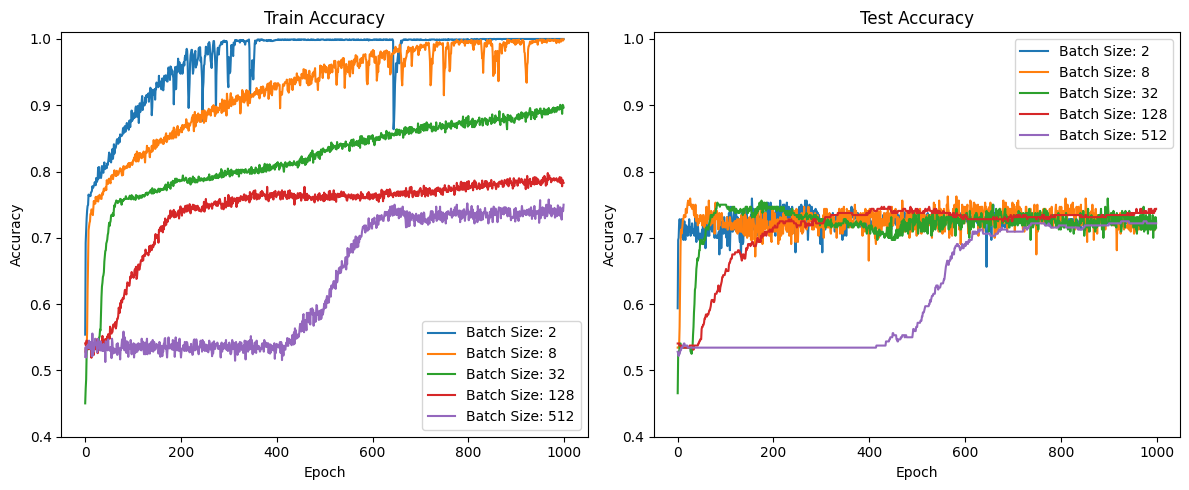

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_accuracies.T)
ax[0].set_title("Train Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend([f"Batch Size: {bs}" for bs in batch_sizes])
ax[0].set_ylim(0.4, 1.01)

ax[1].plot(test_accuracies.T)
ax[1].set_title("Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend([f"Batch Size: {bs}" for bs in batch_sizes])
ax[1].set_ylim(0.4, 1.01)

plt.tight_layout()
plt.show()

# here we could say even we see different accuracies in the train set, we should 
# focus on the test set. Where we can see all the models perform similarly.
# Therefore the best solution here may be the batch size 128, since the variance between
# the train and test set is quite similar, which indicates that the model is not overfitting
#  and generalizes well to unseen data.

In [31]:
# Now let's compare the model with batch normalization vs the one without it, using a fixed batch size and learning rate.
n_epochs = 1000
learning_rate = 0.01
batch_size = 32

train_loader = get_batch_loaders(train_ds, batch_size=batch_size)

model = WineQualityModel()
model_withBN = WineQualityModel_withBN()

train_acc, test_acc, losses = train_model(model, learning_rate, train_loader, test_dl, n_epochs)
train_acc_bn, test_acc_bn, losses_bn = train_model(model_withBN, learning_rate, train_loader, test_dl, n_epochs)

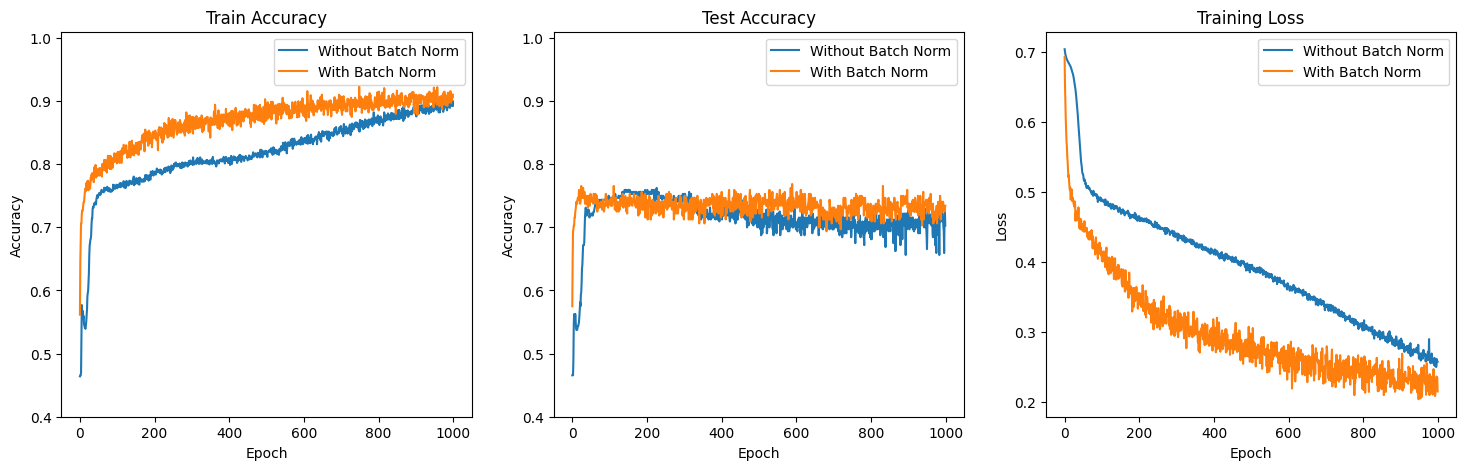

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(train_acc, label="Without Batch Norm")
ax[0].plot(train_acc_bn, label="With Batch Norm")
ax[0].set_title("Train Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].set_ylim(0.4, 1.01)

ax[1].plot(test_acc, label="Without Batch Norm")
ax[1].plot(test_acc_bn, label="With Batch Norm")
ax[1].set_title("Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].set_ylim(0.4, 1.01)

ax[2].plot(losses, label="Without Batch Norm")
ax[2].plot(losses_bn, label="With Batch Norm")
ax[2].set_title("Training Loss")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].legend()

# we can see that with batch norm the model converges faster and reaches a higher accuracy on the train and test set, 
# which indicates that batch normalization is helping the model to learn better representations and generalize better
# to unseen data. In addition, the training loss decreases faster with batch normalization, which also supports the 
# idea that batch norm is improving the optimization process.

In [34]:
# Let's compare different activation functions
n_epochs = 1000
learning_rate = 0.01
batch_size = 32

train_loader = get_batch_loaders(train_ds, batch_size=batch_size)

model_relu = WineQualityModel_Flexible(use_batchnorm=False, act_func=nn.ReLU)
model_sigm = WineQualityModel_Flexible(use_batchnorm=False, act_func=nn.Sigmoid)
model_tanh = WineQualityModel_Flexible(use_batchnorm=False, act_func=nn.Tanh)

train_acc_relu, test_acc_relu, losses_relu = train_model(model_relu, learning_rate, train_loader, test_dl, n_epochs)
train_acc_sigm, test_acc_sigm, losses_sigm = train_model(model_sigm, learning_rate, train_loader, test_dl, n_epochs)
train_acc_tanh, test_acc_tanh, losses_tanh = train_model(model_tanh, learning_rate, train_loader, test_dl, n_epochs)

(0.4, 1.01)

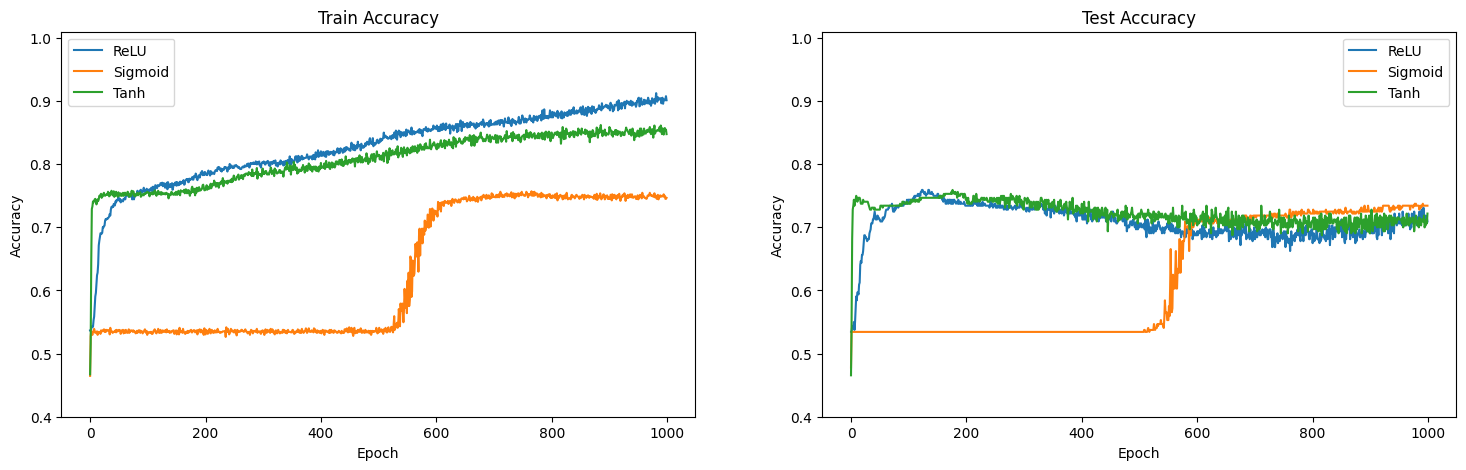

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].plot(train_acc_relu, label="ReLU")
ax[0].plot(train_acc_sigm, label="Sigmoid")
ax[0].plot(train_acc_tanh, label="Tanh")
ax[0].set_title("Train Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].set_ylim(0.4, 1.01)

ax[1].plot(test_acc_relu, label="ReLU")
ax[1].plot(test_acc_sigm, label="Sigmoid")
ax[1].plot(test_acc_tanh, label="Tanh")
ax[1].set_title("Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].set_ylim(0.4, 1.01)

# we can see sigmoid and tanh gets a point where they stop learning and the accuracy plateaus, 
# while ReLU continues to improve and reaches a higher accuracy on the train and test set. 
# This is because sigmoid and tanh can suffer from the vanishing gradient problem, where the 
# gradients become very small for large positive or negative inputs, which can slow down or even 
# stop the learning process. ReLU does not have this issue since it has a constant gradient of 1 
# for positive inputs, which allows it to learn faster and reach better performance in many cases.